In [1]:

import warnings
warnings.filterwarnings('ignore')

# Import Neccessary libraries
import numpy as np 
import pandas as pd 

# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Import Model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

#Import Sampler libraries
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

# Set the decimal format
pd.options.display.float_format = "{:.2f}".format

In [2]:
df = pd.read_csv("/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv")

In [3]:
df.head(2)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,No Info,27.32,6.60,80,0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.00,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.00,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.00,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.00,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.00,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.00,138.06,40.71,80.00,100.00,140.00,159.00,300.00
diabetes,100000.00,0.09,0.28,0.00,0.00,0.00,0.00,1.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(3854)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print(f"unique in {col}= {df[col].nunique()} and unique value is {df[col].unique()[:6]}")

unique in gender= 3 and unique value is ['Female' 'Male' 'Other']
unique in age= 102 and unique value is [80. 54. 28. 36. 76. 20.]
unique in hypertension= 2 and unique value is [0 1]
unique in heart_disease= 2 and unique value is [1 0]
unique in smoking_history= 6 and unique value is ['never' 'No Info' 'current' 'former' 'ever' 'not current']
unique in bmi= 4247 and unique value is [25.19 27.32 23.45 20.14 19.31 23.86]
unique in HbA1c_level= 18 and unique value is [6.6 5.7 5.  4.8 6.5 6.1]
unique in blood_glucose_level= 18 and unique value is [140  80 158 155  85 200]
unique in diabetes= 2 and unique value is [0 1]


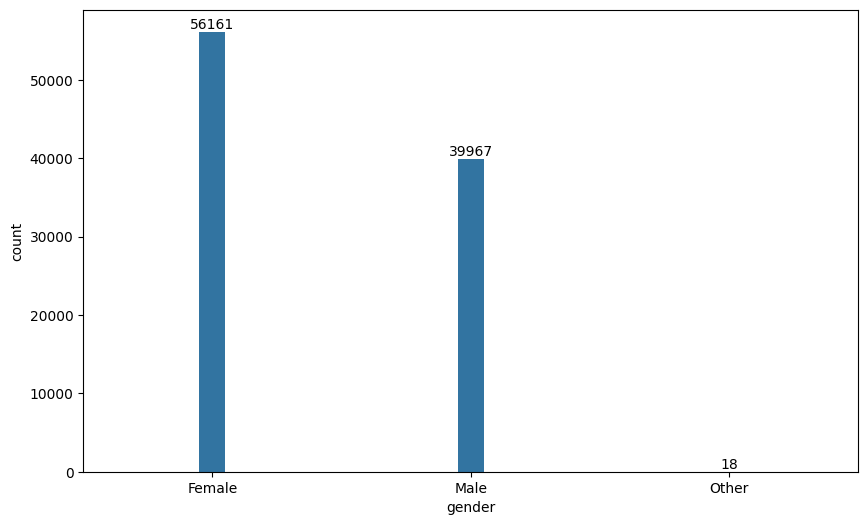

In [11]:

plt.figure(figsize = (10 , 6))
ax = sns.countplot(x='gender' , data = df , width = 0.1 )
ax.bar_label(ax.containers[0])
plt.show()

In [12]:
df = df[df['gender'] != 'Other']

In [13]:
df['gender'].nunique()

2

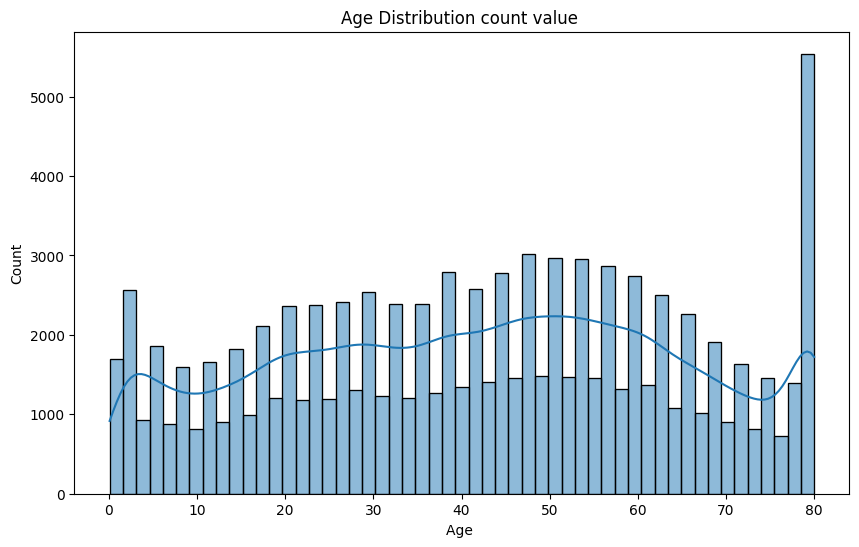

In [14]:
plt.figure(figsize = (10 , 6))
sns.histplot(x = 'age' , data = df , kde = True)
plt.xlabel('Age ')
plt.title('Age Distribution count value ')
plt.show()

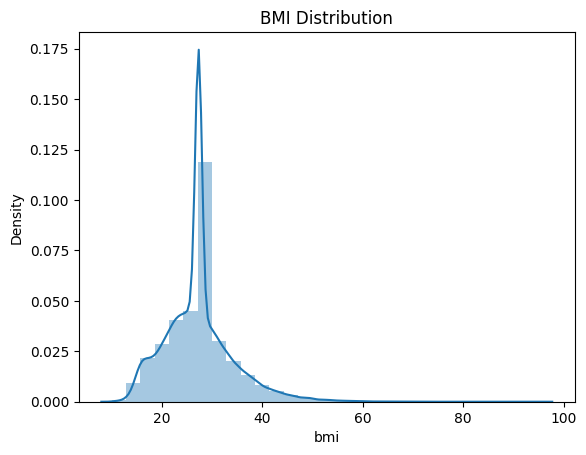

In [15]:
sns.distplot(df['bmi'], bins=30)
plt.title('BMI Distribution')
plt.show()

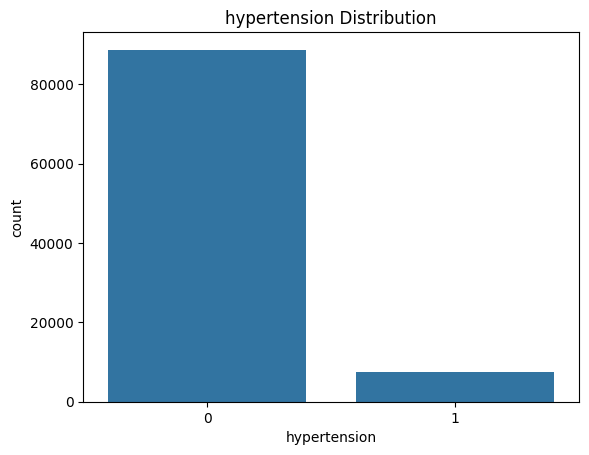

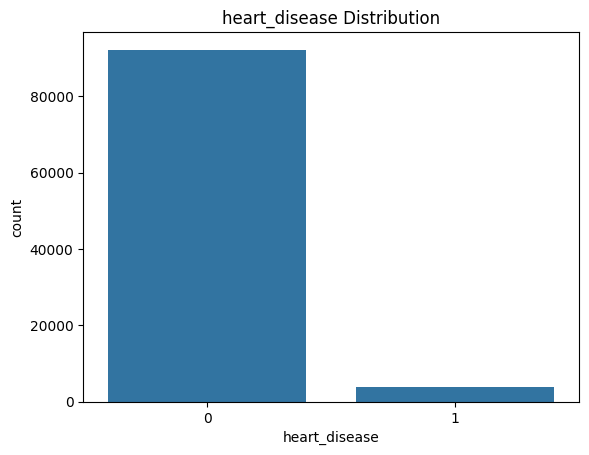

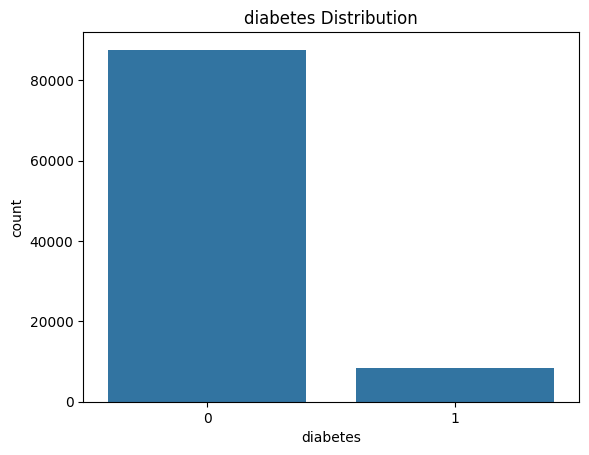

In [16]:
for col in ['hypertension', 'heart_disease', 'diabetes']:
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Distribution')
    plt.show()

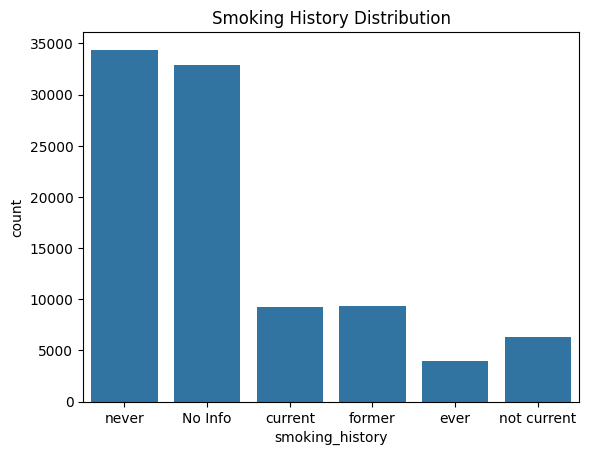

In [17]:
sns.countplot(x='smoking_history', data=df)
plt.title('Smoking History Distribution')
plt.show()

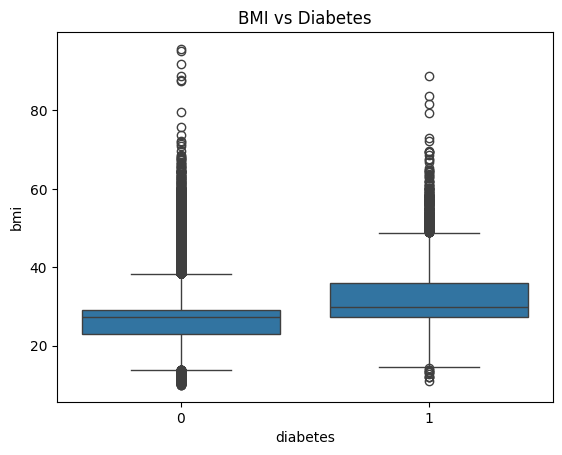

In [18]:
sns.boxplot(x='diabetes', y='bmi', data=df)
plt.title('BMI vs Diabetes')
plt.show()

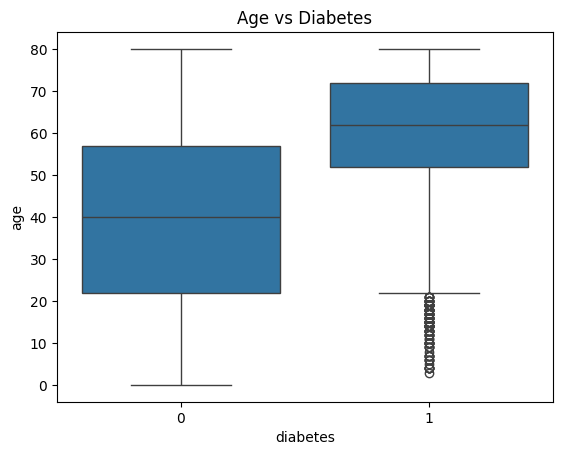

In [19]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age vs Diabetes')
plt.show()

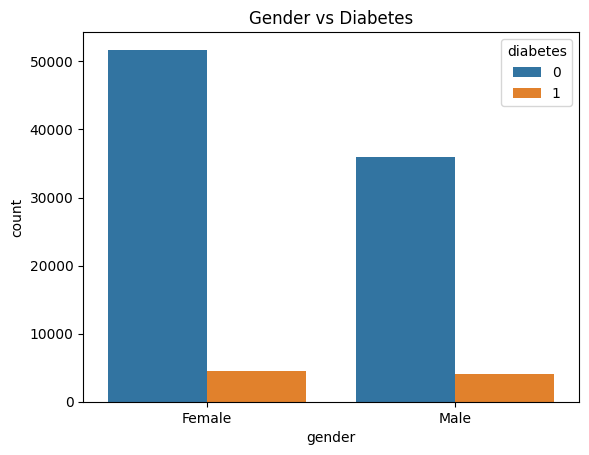

In [20]:
sns.countplot(x='gender', hue='diabetes', data=df)
plt.title('Gender vs Diabetes')
plt.show()

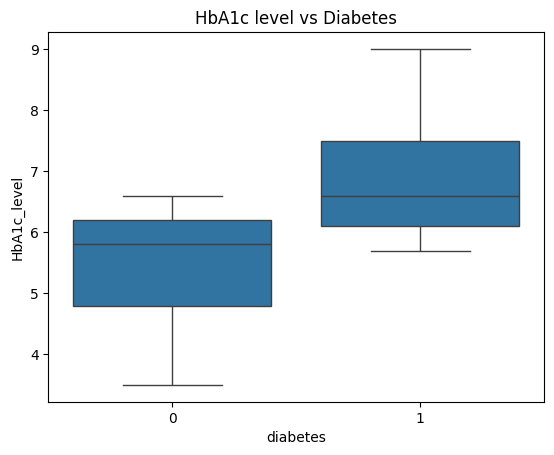

In [21]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title('HbA1c level vs Diabetes')
plt.show()

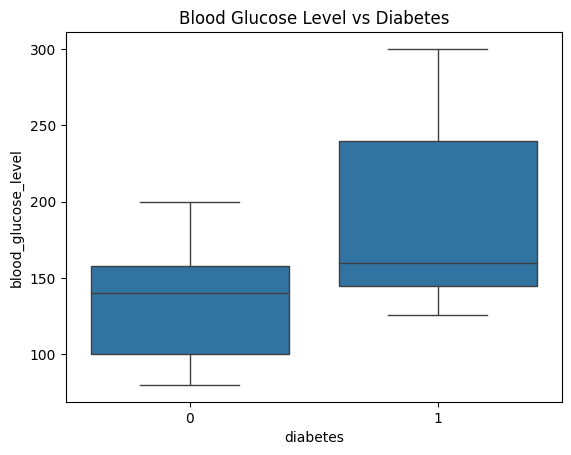

In [22]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.title('Blood Glucose Level vs Diabetes')
plt.show()

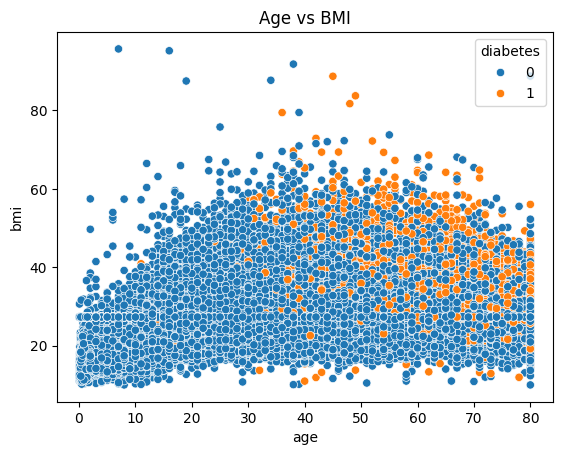

In [23]:
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df)
plt.title('Age vs BMI')
plt.show()

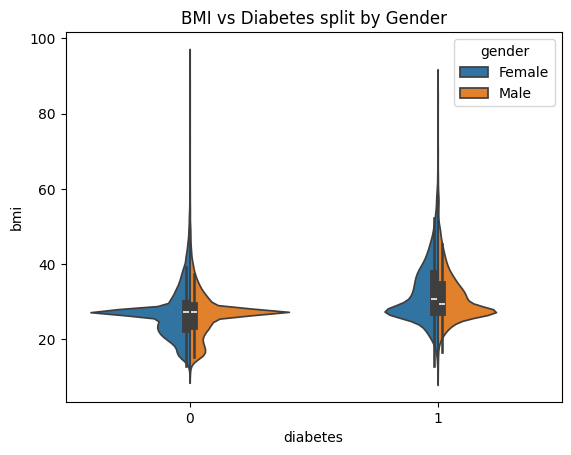

In [24]:
sns.violinplot(x='diabetes', y='bmi', hue='gender', split=True, data=df)
plt.title('BMI vs Diabetes split by Gender')
plt.show()

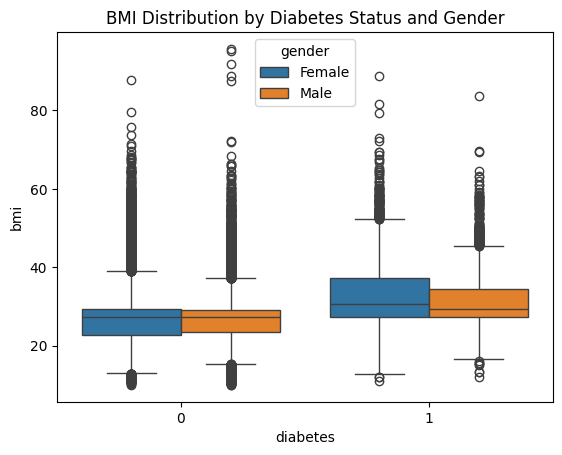

In [25]:
sns.boxplot(x='diabetes', y='bmi', hue='gender', data=df)
plt.title('BMI Distribution by Diabetes Status and Gender')
plt.show()

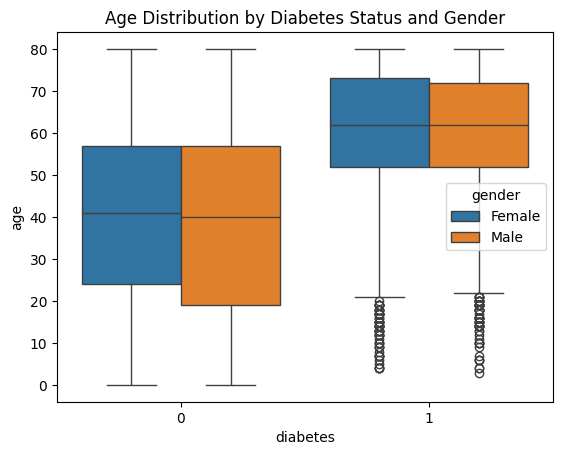

In [26]:
sns.boxplot(x='diabetes', y='age', hue='gender', data=df)
plt.title('Age Distribution by Diabetes Status and Gender')
plt.show()

In [27]:
def recategorised_smoking(smoking_status):
    if smoking_status in ['never', 'No Info']:
        return 'non smoker'
    elif smoking_status in ['ever', 'former', 'not current']:
        return 'past smoker'
    elif smoking_status == 'current':
        return 'current'

df['smoking_history'] = df['smoking_history'].apply(recategorised_smoking)

df['smoking_history'].value_counts()

smoking_history
non smoker     67276
past smoker    19655
current         9197
Name: count, dtype: int64

In [28]:
data = df.copy()

In [29]:
data.head(1)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,non smoker,25.19,6.60,140,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96128 non-null  object 
 1   age                  96128 non-null  float64
 2   hypertension         96128 non-null  int64  
 3   heart_disease        96128 non-null  int64  
 4   smoking_history      96128 non-null  object 
 5   bmi                  96128 non-null  float64
 6   HbA1c_level          96128 non-null  float64
 7   blood_glucose_level  96128 non-null  int64  
 8   diabetes             96128 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [31]:
num_cols = [col for col in df.select_dtypes('number').columns if col != 'diabetes']
cat_cols = df.select_dtypes(include ='object').columns

print(f"{len(num_cols)} and {len(cat_cols)}")

6 and 2


In [32]:
X = df.drop(columns = 'diabetes')
y = df['diabetes']

In [33]:
over = SMOTE(sampling_strategy=0.1)
RUS = RandomUnderSampler(sampling_strategy = 0.5)

In [34]:
preprocessor = ColumnTransformer(transformers=[
    ('std_col' , StandardScaler() , num_cols),
    ('ohe' , OneHotEncoder(handle_unknown ='ignore' , sparse_output = False) , cat_cols )
],remainder='passthrough')

In [35]:
X_temp , X_test , y_temp , y_test = train_test_split(X , y ,test_size=0.15 ,
                                                     stratify =y, random_state = 42)
X_train , X_val , y_train , y_val=train_test_split(X_temp , y_temp , test_size=0.17 ,
                                                  stratify=y_temp , random_state =42)

In [36]:
reg_pipe = imbPipeline(steps=[
    ('preprocessor' , preprocessor),
    ('over' , over),
    ('RandomSampler' , RUS),
    ('RandomForest', RandomForestClassifier(class_weight ='balanced', random_state = 42))
])

param_grid = {
    'RandomForest__n_estimators':[100 , 200 , 300],
    'RandomForest__max_depth' :[None , 10 , 20],
    'RandomForest__min_samples_split': [2 ,5 ,10]
}
grid_search = GridSearchCV(reg_pipe , param_grid , cv = 5 , scoring ='f1' , n_jobs =-1)

In [37]:
from sklearn.metrics import recall_score, f1_score

grid_search.fit(X_train , y_train)
y_pred = grid_search.predict(X_val)

accuracy = accuracy_score(y_val , y_pred)
recall = recall_score(y_val , y_pred)
f1 = f1_score(y_val , y_pred)
class_report =classification_report(y_val , y_pred)
cm = confusion_matrix(y_val , y_pred)

print("model traning succefully completed ...")

print(f"score of model is accuracy = {accuracy} , recall = {recall} , f1 = {f1} , class_report ={class_report} ")
print(cm)

model traning succefully completed ...
score of model is accuracy = 0.9379454322942913 , recall = 0.8393148450244698 , f1 = 0.7047945205479452 , class_report =              precision    recall  f1-score   support

           0       0.98      0.95      0.97     12665
           1       0.61      0.84      0.70      1226

    accuracy                           0.94     13891
   macro avg       0.80      0.89      0.84     13891
weighted avg       0.95      0.94      0.94     13891
 
[[12000   665]
 [  197  1029]]


# **Deep Learning **

In [38]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

In [39]:
X_train_smote , y_train_smote = over.fit_resample(X_train_transformed , y_train )

X_train_resampled , y_train_resampled = RUS.fit_resample(X_train_smote , y_train_smote)

print("Original train size" ,X_train_transformed.shape[0])
print("Batch train size for ANN" , X_train_resampled.shape[0])

Original train size 67817
Batch train size for ANN 18549


In [40]:
input_dim = X_train_resampled.shape[1]
print(f"Total input features for ANN model is {input_dim}")

Total input features for ANN model is 11


In [41]:
import torch
import torch.nn as nn

input_dim = 11 #no of feature in data
hidden_dim = 64 #number of neurons in hidden layen
output_dim =1 #1 because we have to predict one output from 0 and 1
learning_rate =0.003 #learning speed of model
batch_size = 64
epochs = 50

if torch.cuda.is_available():
    device ="cuda"
else:
    device ="cpu"
print(f"our model will run on {device}")

our model will run on cpu


In [42]:
from torch.utils.data import TensorDataset , DataLoader

#1. Change numpy array inti Tensors(float32)
X_train_tensor = torch.tensor(X_train_resampled , dtype = torch.float32)

# y_train_resampled is a series , so we use .values and make the shape of (N ,1 )by .unsqueeze(1)
y_train_tensor = torch.tensor(y_train_resampled.values , dtype = torch.float32).unsqueeze(1)

#add the both data in single dataset
train_dataset = TensorDataset(X_train_tensor , y_train_tensor)

#make a Dataoader that supply data in the form of batch of 64 during training time
train_loader = DataLoader(train_dataset , batch_size = batch_size , shuffle = True)

print(f"Total Number of batches {len(train_loader)} and total rows in all batch is {batch_size}")


Total Number of batches 290 and total rows in all batch is 64


In [43]:
#1. Input Layer se Hidden Layer ( 11 columns se 64 neurons)
#Linear layer = Input * weight + Bias just like Y = mx + c
#11 input feat ---> 64 neurons
layer1 = nn.Linear(input_dim , 64)

#2. Batch Normalization ( it is use for scaling and keep stabel the Data )
bn1 = nn.BatchNorm1d(64)

#3. Activation Function use for learning complex pattern 
relu1 = nn.ReLU()

#4. Dropout Layer (this feature is use for kept away the model from overfitting)
drop1 = nn.Dropout(0.2)

#5. ---Layer 2 (64 neurons --> 32 neurons)
layer2 = nn.Linear(64 , 32)
bn2 = nn.BatchNorm1d(32)
relu2 = nn.ReLU()
drop2 = nn.Dropout(0.2)

#---Layer 3 ( 32 neurons --16 neurons)
layer3 = nn.Linear(32 , 16)
bn3 = nn.BatchNorm1d(16)
relu3 = nn.ReLU()
drop3 = nn.Dropout(0.2)

#6. final activation = Sigmoid - use for convert output in probabilities
out_layer = nn.Linear(16 , output_dim)
sigmoid = nn.Sigmoid()

#7. add all the layers to make sequential model 
ann_model = nn.Sequential(
    layer1, bn1 , relu1 , drop1,
    layer2 , bn2 , relu2 , drop2,
    layer3 , bn3 , relu3 , drop3,
    out_layer , sigmoid
).to(device)

print(ann_model)

Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=32, out_features=16, bias=True)
  (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.2, inplace=False)
  (12): Linear(in_features=16, out_features=1, bias=True)
  (13): Sigmoid()
)


In [44]:
#1. Binary Classification - standard loss function 
criterion = nn.BCELoss()

#2. optimizer = pass the parameter and learning rate 
optimizer = torch.optim.Adam(ann_model.parameters() , lr = learning_rate)

print("Loss Function and optimizer set successfully")

print(f"Optimizer setup : {optimizer}")

Loss Function and optimizer set successfully
Optimizer setup : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.003
    maximize: False
    weight_decay: 0
)


In [45]:
print("Training start .....\n")

#1. loops for epochs
for epoch in range(1 , epochs+1):
    running_loss = 0.0

    #model ----in training( to activate batchNorm and dropout)
    ann_model.train()
    #2 loops for batches ( DataLoader -- 64 data extract )
    for batch_idx , (data , targets) in enumerate(train_loader):
        #send data to gpu
        data , targets = data.to(device), targets.to(device)
        #Step A - clear the old gradients(history)
        optimizer.zero_grad()
        #stepB : Forward Pass ( extract prediction from model)
        outputs = ann_model(data)
        #stepC - Calculate the loss (difference of prediction and real result)
        loss = criterion(outputs , targets)
        #stepD - Backward Pass ( calculate gradients / error)
        loss.backward()
        #stepE - optimizer step (Update the Weights )
        optimizer.step()
        #stepF - addin the loss
        running_loss += loss.item()
    #print average loss of each epochs
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch}/{epochs}] -------> Loss: {epoch_loss:.4f}")

print("|nTraining Successfully Completed! ")

Training start .....

Epoch [1/50] -------> Loss: 0.3009
Epoch [2/50] -------> Loss: 0.2334
Epoch [3/50] -------> Loss: 0.2231
Epoch [4/50] -------> Loss: 0.2215
Epoch [5/50] -------> Loss: 0.2181
Epoch [6/50] -------> Loss: 0.2148
Epoch [7/50] -------> Loss: 0.2151
Epoch [8/50] -------> Loss: 0.2126
Epoch [9/50] -------> Loss: 0.2127
Epoch [10/50] -------> Loss: 0.2111
Epoch [11/50] -------> Loss: 0.2130
Epoch [12/50] -------> Loss: 0.2106
Epoch [13/50] -------> Loss: 0.2109
Epoch [14/50] -------> Loss: 0.2107
Epoch [15/50] -------> Loss: 0.2138
Epoch [16/50] -------> Loss: 0.2095
Epoch [17/50] -------> Loss: 0.2079
Epoch [18/50] -------> Loss: 0.2060
Epoch [19/50] -------> Loss: 0.2068
Epoch [20/50] -------> Loss: 0.2071
Epoch [21/50] -------> Loss: 0.2081
Epoch [22/50] -------> Loss: 0.2055
Epoch [23/50] -------> Loss: 0.2082
Epoch [24/50] -------> Loss: 0.2102
Epoch [25/50] -------> Loss: 0.2063
Epoch [26/50] -------> Loss: 0.2057
Epoch [27/50] -------> Loss: 0.2039
Epoch [28/50] -

In [46]:
#1. change validation data in tensor
X_val_tensor = torch.tensor(X_val_transformed , dtype = torch.float32).to(device)

#model ---evaluation(training) mode
#Dropout and BatchNorm layers got freeze temporary
ann_model.eval()

#3. Stop the gradients calculation(because now we have to predict not to train)
with torch.no_grad():
    #extract the raw probabilities from model ( 0.0 to 1.0)
    val_preds_prob = ann_model(X_val_tensor)
    #if probability > 0.5 then output will be 1 (Diabities) else 0(No Diabetes)
    val_preds = (val_preds_prob >0.5).float()
#4. convert tensor into numpy arrays for sklearn
y_val_pred_numpy = val_preds.cpu().numpy()

#metrics calculation
from sklearn.metrics import accuracy_score , recall_score , f1_score , confusion_matrix , classification_report

print("Deep Learning Model Performance")
print(f"Accuracy of DL model is {accuracy_score(y_val , y_val_pred_numpy):.4f}")
print(f"Recall   : {recall_score(y_val, y_val_pred_numpy):.4f} (Most important)")
print(f"F1-Score : {f1_score(y_val, y_val_pred_numpy):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_numpy))

Deep Learning Model Performance
Accuracy of DL model is 0.9323
Recall   : 0.8654 (Most important)
F1-Score : 0.6930

Confusion Matrix:
[[11890   775]
 [  165  1061]]


In [47]:
import joblib

# grid_search.best_estimator_ --> best tuned model pipeline 
best_rf_model = grid_search.best_estimator_

# Model  'random_forest_model.pkl' name  save 
joblib.dump(best_rf_model, 'random_forest_model.pkl')

print("Random Forest Model successfully save: 'random_forest_model.pkl'")

Random Forest Model successfully save: 'random_forest_model.pkl'


In [48]:
# ANN save the model  weights in 'diabetes_ann_model.pt' 
torch.save(ann_model.state_dict(), 'diabetes_ann_model.pt')

print("PyTorch ANN Model successfully save : 'diabetes_ann_model.pt'")

PyTorch ANN Model successfully save : 'diabetes_ann_model.pt'


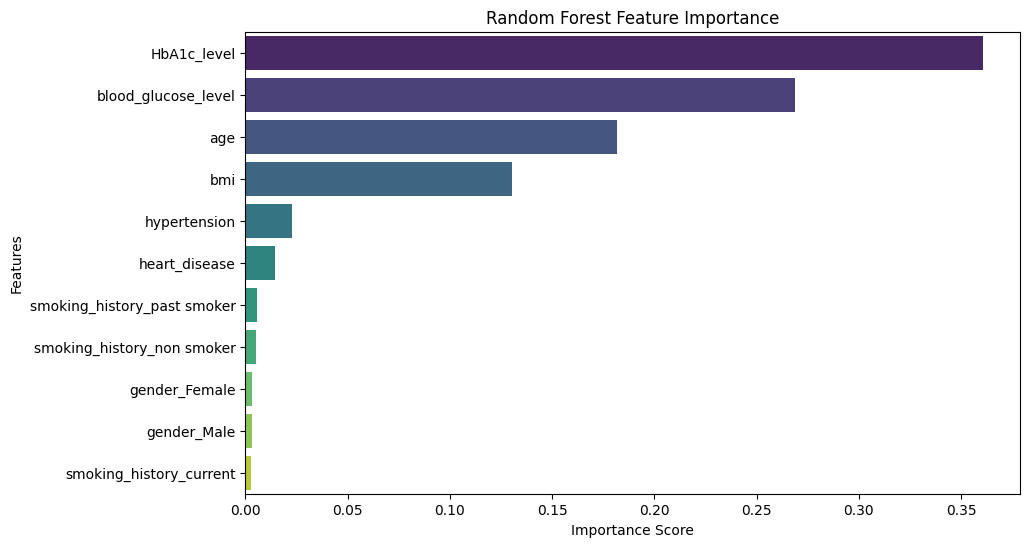

                    Feature  Importance
                HbA1c_level        0.36
        blood_glucose_level        0.27
                        age        0.18
                        bmi        0.13
               hypertension        0.02
              heart_disease        0.01
smoking_history_past smoker        0.01
 smoking_history_non smoker        0.01
              gender_Female        0.00
                gender_Male        0.00
    smoking_history_current        0.00


In [49]:
# --- CELL 53: RANDOM FOREST FEATURE IMPORTANCE ---

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pipeline se actual random forest model aur features ke naam nikalna
rf_model_actual = grid_search.best_estimator_.named_steps['RandomForest']

# Hamare preprocessor ne numerical aur categorical columns ko transform kiya hai, unke sahi naam nikalna:
ohe_cols = list(grid_search.best_estimator_.named_steps['preprocessor'].named_transformers_['ohe'].get_feature_names_out(cat_cols))
all_features = num_cols + ohe_cols

# 2. Importance values 
importances = rf_model_actual.feature_importances_

# DataFrame help in plotting
rf_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Top features print 
print(rf_importance_df.to_string(index=False))